In [3]:
# Imports principales
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from collections import Counter
import time # Para medir el tiempo de entrenamiento

# Modelos y métricas
from sklearn.model_selection import train_test_split, learning_curve, GridSearchCV
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc, classification_report, accuracy_score
from sklearn.pipeline import Pipeline

# Clasificador
from sklearn.svm import SVC
from sklearn.multiclass import OneVsRestClassifier # Necesario para la Curva ROC de múltiples clases

# Configuración de matplotlib para gráficos
plt.rcParams['figure.figsize'] = (8, 6)
plt.rcParams['font.size'] = 12

    

In [29]:
# --- Carga de Datos ---
try:
    df = pd.read_csv('dataset_limpio.csv')
    print("Datos cargados exitosamente. Forma:", df.shape)
except FileNotFoundError:
    print("ERROR: El archivo 'dataset_limpio.csv' no fue encontrado.")

Datos cargados exitosamente. Forma: (30905, 9)


In [30]:
# Identificar la variable objetivo (target)
target_col = 'particle_type'

# Codificación de la variable objetivo (usando 'electron' y 'muon' como ejemplo, 
# si hay más clases, label_binarize se encargará de ellas más adelante)
# Asumimos que la variable 'particle_type' es de tipo string/object.

# Eliminar 'event_id' ya que no es una característica predictiva
if 'event_id' in df.columns:
    df = df.drop('event_id', axis=1)

# Asumiendo que 'particle_type' es la única columna no numérica aparte de 'event_id'
X = df.drop(target_col, axis=1)
y_str = df[target_col]

# Obtener las clases únicas para la codificación
classes = sorted(y_str.unique())
y = pd.Series(y_str.factorize(sort=True)[0], name=target_col) # Codificación a enteros

print("\nConteo de clases en la variable objetivo:")
print(y_str.value_counts())
print("\nClases detectadas (índice a nombre):")
for i, cls in enumerate(classes):
    print(f"Clase {i}: {cls}")

# División en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print(f"\nForma de X_train: {X_train.shape}")
print(f"Forma de X_test: {X_test.shape}")


Conteo de clases en la variable objetivo:
particle_type
track       30111
muon          397
photon        251
electron      146
Name: count, dtype: int64

Clases detectadas (índice a nombre):
Clase 0: electron
Clase 1: muon
Clase 2: photon
Clase 3: track

Forma de X_train: (23178, 7)
Forma de X_test: (7727, 7)


In [32]:
%%time

# 1. Definición del Pipeline
# El StandardScaler es crucial para SVM
svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(random_state=42, probability=True)) # probability=True para Curva ROC
])

# 2. Definición de la grilla de parámetros
# Se recomienda empezar con una grilla pequeña para reducir el tiempo de ejecución.
# El parámetro 'C' controla el costo de penalización por error.
# El parámetro 'gamma' define la influencia de un solo ejemplo de entrenamiento.
param_grid = {
    'svm__C': [0.1, 1, 10],
    'svm__gamma': ['scale', 0.01, 0.1],
    'svm__kernel': ['rbf'] # El kernel RBF es una buena opción inicial
}

# 3. Inicialización del Grid Search con paralelización
# n_jobs=-1 utiliza todos los núcleos disponibles.
# cv=5 es una validación cruzada de 5 pliegues.
grid_search = GridSearchCV(
    svm_pipeline,
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1, # Paralelización
    verbose=2
)

# 4. Entrenamiento
print("\nIniciando el entrenamiento de SVM con Grid Search (Parallelizado)...")
start_time = time.time()
grid_search.fit(X_train, y_train)
end_time = time.time()

# 5. Guardar el mejor modelo y mostrar resultados
best_svm_model = grid_search.best_estimator_
training_time = end_time - start_time

print("--- Resultados del Grid Search ---")
print(f"Tiempo de entrenamiento total: {training_time:.2f} segundos")
print(f"Mejores hiperparámetros encontrados: {grid_search.best_params_}")
print(f"Mejor precisión de validación cruzada: {grid_search.best_score_:.4f}")

# La predicción para las métricas se realizará con el mejor estimador
y_pred = best_svm_model.predict(X_test)


Iniciando el entrenamiento de SVM con Grid Search (Parallelizado)...
Fitting 5 folds for each of 9 candidates, totalling 45 fits
--- Resultados del Grid Search ---
Tiempo de entrenamiento total: 84.84 segundos
Mejores hiperparámetros encontrados: {'svm__C': 10, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}
Mejor precisión de validación cruzada: 0.9816
CPU times: total: 24.7 s
Wall time: 1min 25s



--- Reporte de Clasificación en el conjunto de Prueba ---
              precision    recall  f1-score   support

    electron       0.20      0.03      0.05        37
        muon       0.00      0.00      0.00        99
      photon       1.00      0.98      0.99        63
       track       0.98      1.00      0.99      7528

    accuracy                           0.98      7727
   macro avg       0.55      0.50      0.51      7727
weighted avg       0.97      0.98      0.97      7727


--- Matriz de Confusión ---


<Figure size 1000x800 with 0 Axes>

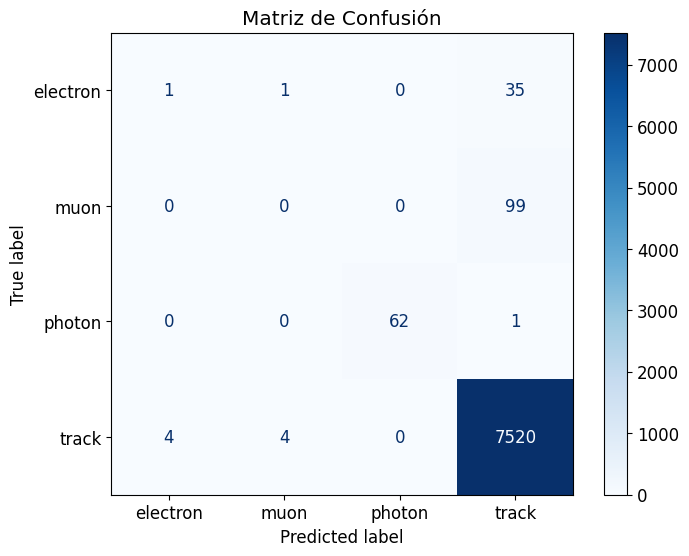


--- Recall (Precisión por Clase/Sensibilidad) ---
Recall para electron: 0.0270
Recall para muon: 0.0000
Recall para photon: 0.9841
Recall para track: 0.9989


In [33]:
# --- 1. Reporte de Clasificación ---
print("\n--- Reporte de Clasificación en el conjunto de Prueba ---")
# 'target_names' utiliza las etiquetas de clase reales.
print(classification_report(y_test, y_pred, target_names=classes))

# --- 2. Matriz de Confusión ---
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)

print("\n--- Matriz de Confusión ---")
# 
plt.figure(figsize=(10, 8))
disp.plot(cmap=plt.cm.Blues, values_format='d')
plt.title('Matriz de Confusión')
plt.grid(False) # Quitar la cuadrícula para la matriz de confusión
plt.show()

# --- 3. Precisión por Clase (Accuracy per Class) ---
# La precisión por clase se obtiene de la diagonal de la matriz de confusión dividida por
# la suma de la fila (ejemplos reales de esa clase). Esto se llama *Recall* o *Sensibilidad*
# y ya está en el reporte de clasificación, pero se calcula directamente aquí para
# la métrica específica si es requerida como métrica de la matriz.

class_recall = cm.diagonal() / cm.sum(axis=1)
print("\n--- Recall (Precisión por Clase/Sensibilidad) ---")
for i, cls in enumerate(classes):
    print(f"Recall para {cls}: {class_recall[i]:.4f}")


Generando Curva ROC...


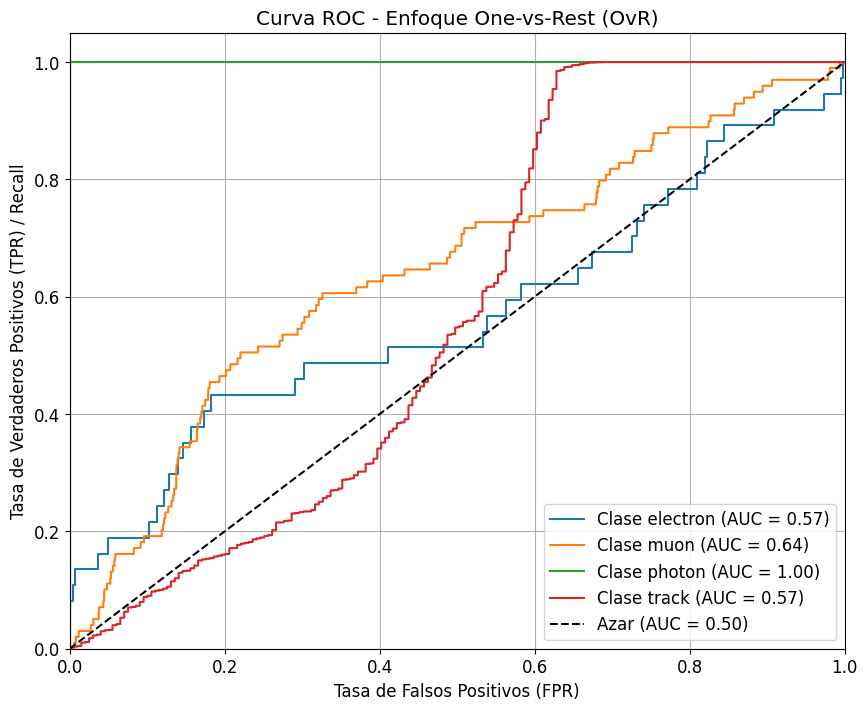

In [34]:
# --- Curva ROC (Multiclase: One-vs-Rest) ---
print("\nGenerando Curva ROC...")

# Convertir las etiquetas y_test a formato binario (one-hot encoding)
y_test_binarized = label_binarize(y_test, classes=range(len(classes)))
n_classes = y_test_binarized.shape[1]

# Obtener las probabilidades de predicción del modelo
# Necesita 'probability=True' en el SVC.
y_score = best_svm_model.predict_proba(X_test)

# Calcular la Curva ROC y el AUC para cada clase
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_binarized[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# 


# Trazar la Curva ROC
plt.figure(figsize=(10, 8))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f'Clase {classes[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Azar (AUC = 0.50)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR) / Recall')
plt.title('Curva ROC - Enfoque One-vs-Rest (OvR)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


Calculando Curva de Aprendizaje...


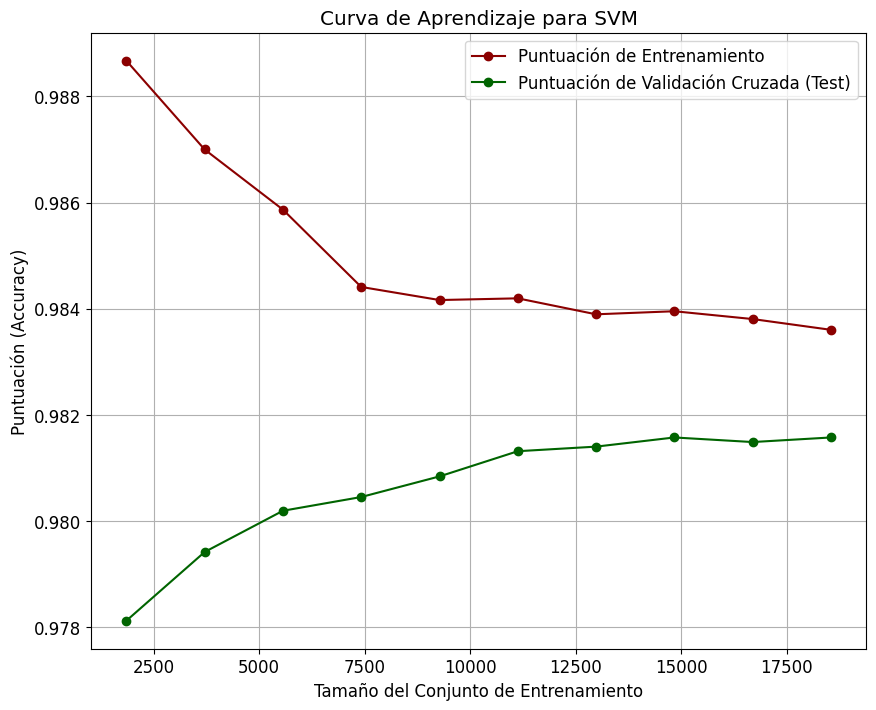


Fin del proceso de entrenamiento y evaluación.


In [36]:
# --- Curva de Aprendizaje ---
print("\nCalculando Curva de Aprendizaje...")

# Usar el mejor estimador del Grid Search para la curva
# No se vuelve a entrenar, se usa la métrica de validación cruzada.
train_sizes, train_scores, test_scores = learning_curve(
    best_svm_model, # El modelo ya entrenado (best_estimator_)
    X_train,        # Usar X_train para calcular la curva
    y_train,
    cv=5,
    train_sizes=np.linspace(0.1, 1.0, 10), # 10 puntos, del 10% al 100% de los datos de entrenamiento
    scoring='accuracy',
    n_jobs=-1 # Paralelización también para el cálculo
)

# Calcular las medias de las puntuaciones
train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

# 


# Trazar la Curva de Aprendizaje
plt.figure(figsize=(10, 8))
plt.plot(train_sizes, train_mean, 'o-', color="darkred", label="Puntuación de Entrenamiento")
plt.plot(train_sizes, test_mean, 'o-', color="darkgreen", label="Puntuación de Validación Cruzada (Test)")

plt.title('Curva de Aprendizaje para SVM')
plt.xlabel('Tamaño del Conjunto de Entrenamiento')
plt.ylabel('Puntuación (Accuracy)')
plt.legend(loc="best")
plt.grid(True)
plt.show()

print("\nFin del proceso de entrenamiento y evaluación.")

## SIN TRACKS

In [37]:
# --- Carga de Datos ---
try:
    df = pd.read_csv("dataset_limpio_notracks.csv")
    print("Datos cargados exitosamente. Forma:", df.shape)
except FileNotFoundError:
    print("ERROR: El archivo dataset_limpio_notracks.csv no fue encontrado.")

Datos cargados exitosamente. Forma: (794, 9)


In [38]:
# Identificar la variable objetivo (target)
target_col = 'particle_type'

# Codificación de la variable objetivo (usando 'electron' y 'muon' como ejemplo, 
# si hay más clases, label_binarize se encargará de ellas más adelante)
# Asumimos que la variable 'particle_type' es de tipo string/object.

# Eliminar 'event_id' ya que no es una característica predictiva
if 'event_id' in df.columns:
    df = df.drop('event_id', axis=1)

# Asumiendo que 'particle_type' es la única columna no numérica aparte de 'event_id'
X = df.drop(target_col, axis=1)
y_str = df[target_col]

# Obtener las clases únicas para la codificación
classes = sorted(y_str.unique())
y = pd.Series(y_str.factorize(sort=True)[0], name=target_col) # Codificación a enteros

print("\nConteo de clases en la variable objetivo:")
print(y_str.value_counts())
print("\nClases detectadas (índice a nombre):")
for i, cls in enumerate(classes):
    print(f"Clase {i}: {cls}")

# División en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print(f"\nForma de X_train: {X_train.shape}")
print(f"Forma de X_test: {X_test.shape}")


Conteo de clases en la variable objetivo:
particle_type
muon        397
photon      251
electron    146
Name: count, dtype: int64

Clases detectadas (índice a nombre):
Clase 0: electron
Clase 1: muon
Clase 2: photon

Forma de X_train: (595, 7)
Forma de X_test: (199, 7)


In [39]:
%%time
# 1. Definición del Pipeline
# El StandardScaler es crucial para SVM
svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(random_state=42, probability=True)) # probability=True para Curva ROC
])

# 2. Definición de la grilla de parámetros
# Se recomienda empezar con una grilla pequeña para reducir el tiempo de ejecución.
# El parámetro 'C' controla el costo de penalización por error.
# El parámetro 'gamma' define la influencia de un solo ejemplo de entrenamiento.
param_grid = {
    'svm__C': [0.1, 1, 10],
    'svm__gamma': ['scale', 0.01, 0.1],
    'svm__kernel': ['rbf'] # El kernel RBF es una buena opción inicial
}

# 3. Inicialización del Grid Search con paralelización
# n_jobs=-1 utiliza todos los núcleos disponibles.
# cv=5 es una validación cruzada de 5 pliegues.
grid_search = GridSearchCV(
    svm_pipeline,
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1, # Paralelización
    verbose=2
)

# 4. Entrenamiento
print("\nIniciando el entrenamiento de SVM con Grid Search (Parallelizado)...")
start_time = time.time()
grid_search.fit(X_train, y_train)
end_time = time.time()

# 5. Guardar el mejor modelo y mostrar resultados
best_svm_model = grid_search.best_estimator_
training_time = end_time - start_time

print("--- Resultados del Grid Search ---")
print(f"Tiempo de entrenamiento total: {training_time:.2f} segundos")
print(f"Mejores hiperparámetros encontrados: {grid_search.best_params_}")
print(f"Mejor precisión de validación cruzada: {grid_search.best_score_:.4f}")

# La predicción para las métricas se realizará con el mejor estimador
y_pred = best_svm_model.predict(X_test)


Iniciando el entrenamiento de SVM con Grid Search (Parallelizado)...
Fitting 5 folds for each of 9 candidates, totalling 45 fits
--- Resultados del Grid Search ---
Tiempo de entrenamiento total: 0.29 segundos
Mejores hiperparámetros encontrados: {'svm__C': 1, 'svm__gamma': 0.1, 'svm__kernel': 'rbf'}
Mejor precisión de validación cruzada: 0.8504
CPU times: total: 93.8 ms
Wall time: 293 ms



--- Reporte de Clasificación en el conjunto de Prueba ---
              precision    recall  f1-score   support

    electron       0.82      0.24      0.38        37
        muon       0.77      0.97      0.86        99
      photon       0.98      1.00      0.99        63

    accuracy                           0.84       199
   macro avg       0.86      0.74      0.74       199
weighted avg       0.85      0.84      0.81       199


--- Matriz de Confusión ---


<Figure size 1000x800 with 0 Axes>

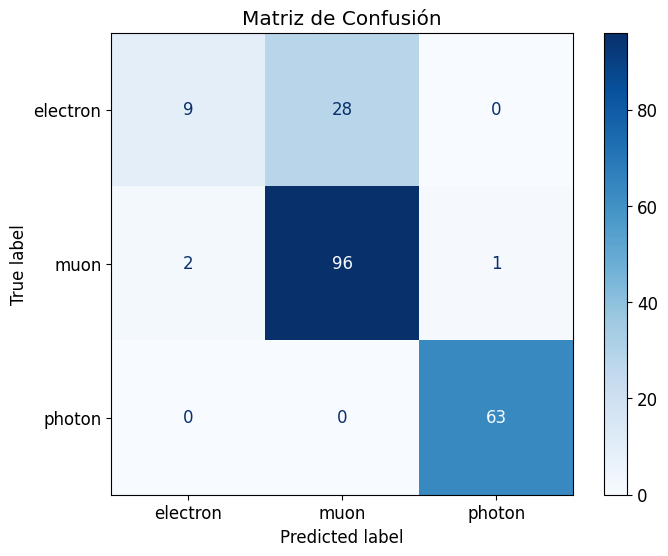


--- Recall (Precisión por Clase/Sensibilidad) ---
Recall para electron: 0.2432
Recall para muon: 0.9697
Recall para photon: 1.0000


In [40]:
# --- 1. Reporte de Clasificación ---
print("\n--- Reporte de Clasificación en el conjunto de Prueba ---")
# 'target_names' utiliza las etiquetas de clase reales.
print(classification_report(y_test, y_pred, target_names=classes))

# --- 2. Matriz de Confusión ---
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)

print("\n--- Matriz de Confusión ---")
# 
plt.figure(figsize=(10, 8))
disp.plot(cmap=plt.cm.Blues, values_format='d')
plt.title('Matriz de Confusión')
plt.grid(False) # Quitar la cuadrícula para la matriz de confusión
plt.show()

# --- 3. Precisión por Clase (Accuracy per Class) ---
# La precisión por clase se obtiene de la diagonal de la matriz de confusión dividida por
# la suma de la fila (ejemplos reales de esa clase). Esto se llama *Recall* o *Sensibilidad*
# y ya está en el reporte de clasificación, pero se calcula directamente aquí para
# la métrica específica si es requerida como métrica de la matriz.

class_recall = cm.diagonal() / cm.sum(axis=1)
print("\n--- Recall (Precisión por Clase/Sensibilidad) ---")
for i, cls in enumerate(classes):
    print(f"Recall para {cls}: {class_recall[i]:.4f}")


Generando Curva ROC...


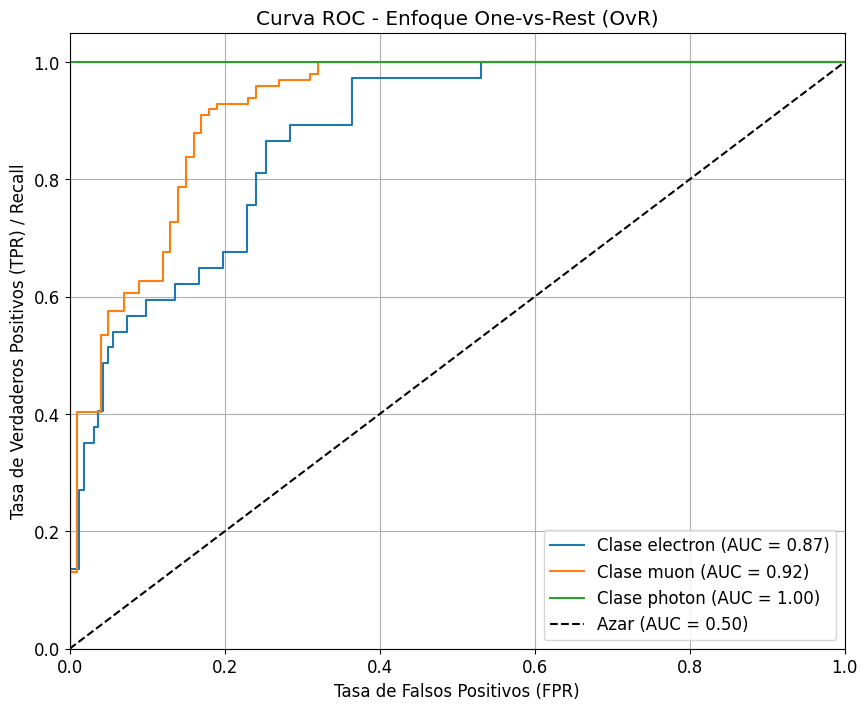

In [27]:
# --- Curva ROC (Multiclase: One-vs-Rest) ---
print("\nGenerando Curva ROC...")

# Convertir las etiquetas y_test a formato binario (one-hot encoding)
y_test_binarized = label_binarize(y_test, classes=range(len(classes)))
n_classes = y_test_binarized.shape[1]

# Obtener las probabilidades de predicción del modelo
# Necesita 'probability=True' en el SVC.
y_score = best_svm_model.predict_proba(X_test)

# Calcular la Curva ROC y el AUC para cada clase
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_binarized[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# 


# Trazar la Curva ROC
plt.figure(figsize=(10, 8))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f'Clase {classes[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Azar (AUC = 0.50)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR) / Recall')
plt.title('Curva ROC - Enfoque One-vs-Rest (OvR)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


Calculando Curva de Aprendizaje...


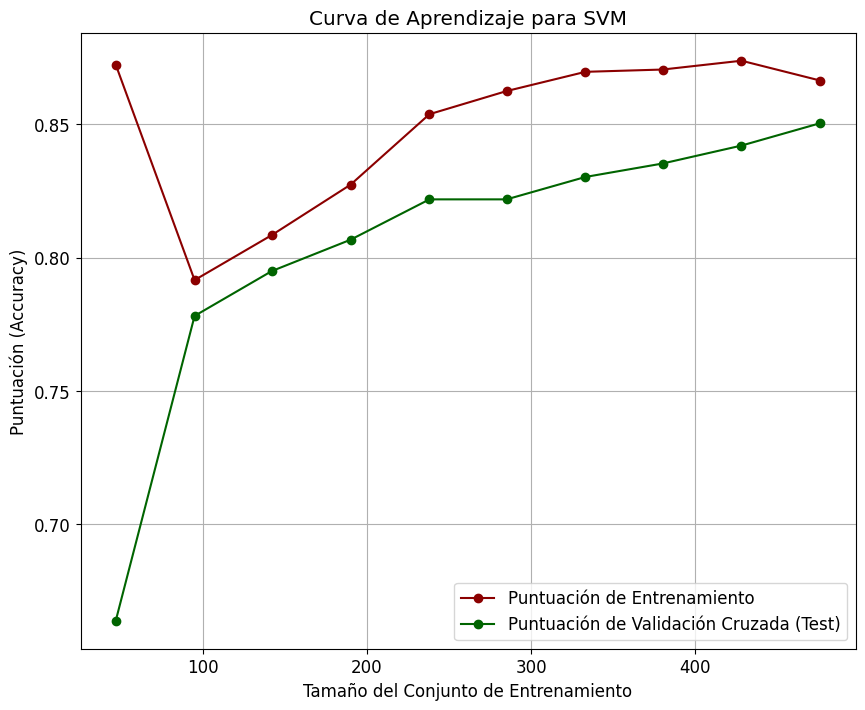


Fin del proceso de entrenamiento y evaluación.


In [41]:
# --- Curva de Aprendizaje ---
print("\nCalculando Curva de Aprendizaje...")

# Usar el mejor estimador del Grid Search para la curva
# No se vuelve a entrenar, se usa la métrica de validación cruzada.
train_sizes, train_scores, test_scores = learning_curve(
    best_svm_model, # El modelo ya entrenado (best_estimator_)
    X_train,        # Usar X_train para calcular la curva
    y_train,
    cv=5,
    train_sizes=np.linspace(0.1, 1.0, 10), # 10 puntos, del 10% al 100% de los datos de entrenamiento
    scoring='accuracy',
    n_jobs=-1 # Paralelización también para el cálculo
)

# Calcular las medias de las puntuaciones
train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

# 


# Trazar la Curva de Aprendizaje
plt.figure(figsize=(10, 8))
plt.plot(train_sizes, train_mean, 'o-', color="darkred", label="Puntuación de Entrenamiento")
plt.plot(train_sizes, test_mean, 'o-', color="darkgreen", label="Puntuación de Validación Cruzada (Test)")

plt.title('Curva de Aprendizaje para SVM')
plt.xlabel('Tamaño del Conjunto de Entrenamiento')
plt.ylabel('Puntuación (Accuracy)')
plt.legend(loc="best")
plt.grid(True)
plt.show()

print("\nFin del proceso de entrenamiento y evaluación.")